# 👋 **Introduction:**
### **🐕🆚🐈 Dog vs Cat Image Classification**

**Business problem:**

**Pedigree** wants to develop an automated food dispenser that will identify between a dog and a cat using image recognition. This device will dispense the correct food type based on the image recognized on a pre-determined or a custom time frequency, thereby improving pet care while also preventing human error.

This will enhance customer satisfaction and will automate the feeding process in multi-pet households while also decreasing costs for pet owners and pet shelters.

**Data collection:**

For data collection, we would need a large and diverse dataset of labeled images consisting of dogs and cats in mutiple different environments. Different lighting conditions and varied environments would further diversify the data.

This data can be collected from open datasets, customer requests or image collection through real world photography.


**Modeling Techniques:**

This problem is a case of `supervised binary image classification` where we need to train the model to predict if the input is either a cat or a dog.

# 📑 **Imports**

In [ ]:
import os
import shutil
from sklearn.model_selection import train_test_split

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

import warnings

# 📥 **Data Loading and Preparation**

The link to my dataset: https://www.kaggle.com/datasets/anthonytherrien/dog-vs-cat/data


In [ ]:
# Source directory containing all 'cat' and 'dog' images
src_dir = 'C:\\Users\\judec\\Downloads\\deep neural network\\animals'
# Destination directory to store test split dataset
test_dir = 'C:\\Users\\judec\\Downloads\\deep neural network\\test_animals'

# Create test directory and subfolders if they don't exist
os.makedirs(test_dir, exist_ok=True)
for class_name in os.listdir(src_dir):
    class_path = os.path.join(test_dir, class_name)
    os.makedirs(class_path, exist_ok=True)

# Split each class folder
test_size = 0.15
for class_name in os.listdir(src_dir):
    class_folder = os.path.join(src_dir, class_name)
    if not os.path.isdir(class_folder):
        continue
    images = os.listdir(class_folder)
    train_imgs, test_imgs = train_test_split(images, test_size=test_size, random_state=42)
    # Move test images to test_dir
    for img in test_imgs:
        src_img = os.path.join(class_folder, img)
        dst_img = os.path.join(test_dir, class_name, img)
        shutil.move(src_img, dst_img)


# 🕵️ **Data Exploration**

## 🖼️ **Data Augmentation**

Applying augmentation on `training dataset` to reduce overfitting:
- Rotation for variance
- Shift horizontally and vertically (width and height)
- Change shear intensity
- Zoom in
- Flip horizontally
- Add brightness range
- Fill in missing pixels after above transformations

`Validation dataset` does not require augmentation.

In [ ]:
# Directory folders where the images of cats and dogs are stored
data_dir = 'C:\\Users\\judec\\Downloads\\deep neural network\\animals'

# Creating ImageDataGenerator object for training with data augmentation
train_datagen = ImageDataGenerator(rescale=1./255, rotation_range=30,
                                   width_shift_range=0.15, height_shift_range=0.15,
                                   shear_range=0.15, zoom_range=0.25,
                                   horizontal_flip=True, brightness_range=[0.8, 1.2],
                                   fill_mode='nearest', validation_split=0.2,)

# Creating ImageDataGenerator object for validation without augmentation
validation_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2,)

# ⚙️ **Data Preprocessing**

Here we create `train_data` and `validation_data` using `flow_from_directory` from `ImageDataGenerator`
- The images are resized to 256x256 using target size.
- To manage memory usage and speed up the training process, we use a batch of 32 samples at a time for training, validating and testing.
- Class mode is mentioned as binary as we are working with a binary classification task.
- No manual feature engineering is required as CNN learns features automatically from provided images.

In [3]:
# Loading training dataset with augmentation
train_data = train_datagen.flow_from_directory(data_dir, target_size=(256, 256),
                                               batch_size=32, class_mode='binary',
                                               subset='training')

# Loading validation dataset without augmentation
validation_data = validation_datagen.flow_from_directory(data_dir, target_size=(256, 256),
                                                         batch_size=32, class_mode='binary',
                                                         subset='validation')

Found 680 images belonging to 2 classes.
Found 170 images belonging to 2 classes.


I have used the test directory folder which was previously created, to create a ImageDataGenerator object for model evaluation. 

It uses a 15% split.

In [4]:
# Directory where the test images of cats and dogs are stored
test_data_dir = 'C:\\Users\\judec\\Downloads\\deep neural network\\test_animals'


# Creating ImageDataGenerator object for test without augmentation
test_datagen = ImageDataGenerator(rescale=1./255,)

# Loading test dataset without augmentation
test_data = test_datagen.flow_from_directory(test_data_dir, target_size=(256, 256),
                                             batch_size=32, class_mode='binary',)

Found 150 images belonging to 2 classes.


Checking the data types, classes and imageshape 

In [5]:
print(type(train_data))         
print(type(validation_data)) 
print(train_data.class_indices)
print(train_data.image_shape)

<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>
<class 'keras.src.legacy.preprocessing.image.DirectoryIterator'>
{'cat': 0, 'dog': 1}
(256, 256, 3)


Checking type of images 

In [6]:
images, labels = next(train_data)  
print(type(images[0])) 

<class 'numpy.ndarray'>


Checking shapes of image and labels 

In [7]:
image, label = train_data[0]  #taking first batch 
print(images.shape) 
print(labels.shape)  

(32, 256, 256, 3)
(32,)


# 😻 **Display some images**

We can see the applied augmentation at work in the training data.

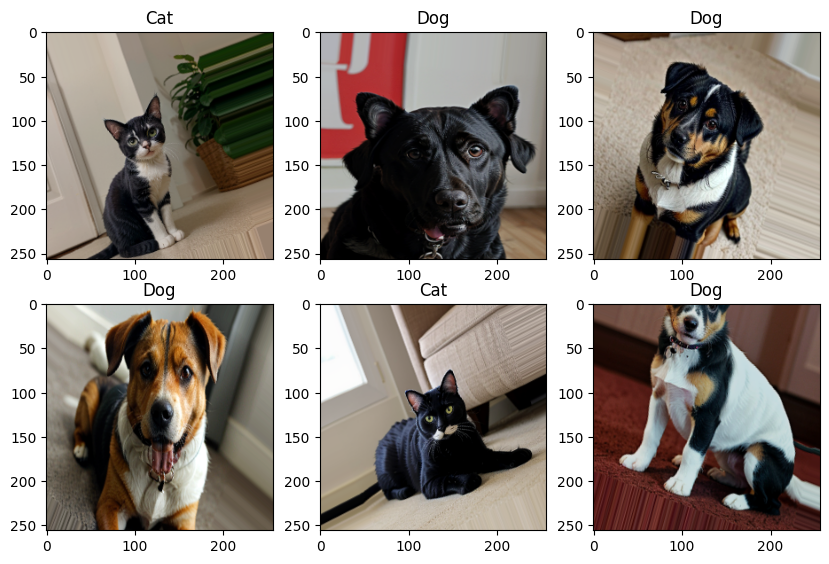

In [8]:
plt.figure(figsize=(10, 10))
for i in range(6):  # Displaying 6 images
    images, labels = train_data[0]  # first batch
    ax = plt.subplot(3, 3, i + 1)   
    plt.imshow(images[i])            
    plt.title('Cat' if labels[i] == 0 else 'Dog')  
plt.show() 

# 🧠 **Model Training**



We use the CNN model (Convolutional Neural Network) using `Kera's Sequential` API as it suits our problem statement requiring image classification.

This model is built layer by layer with input shape as (256, 256, 3) which means 256x256 pixeled RGB image.

- The first layer chosen is a **2D convolutional** layer with 32 filters (each 3x3) and relu is used for activation (helps the network learn complex patterns). The padding = "valid" means no padding is added.
- The next layer is a **max pooling 2D** layer (2x2 window) and a stride of 2 which helps control overfitting.
- The next layer is a pair of layers that repeats a convolutional layer (with 64 filters (3x3), relu activation and valid padding) and another max pooling layer. **Stacking multiple Conv2D and MaxPooling2D layers helps the model to learn complex features from the images.**
- The layers are then flattened into a one dimensional vector using **Flatten layer**. This helps with the following Dense layers.
- Two **Dense layers** (with 128 and 64 units) follow which helps process the features and also helps the model to learn non-linear combinations of them.
- Finally, a **Dense layer** with a single neuron and sigmoid activation is used as an output layer which is ideal for binary classification. This gets us a 0 or 1 output for dog/cat, helping us with the image classification.

The model is then complied with the `Adam optimizer` and `binary cross-entropy loss` which helps output binary classification. This is then trained using an unfamiliar augumented training data while monitoring validation accuracy.

Ignore UserWarning messages

In [9]:
warnings.filterwarnings("ignore", category=UserWarning)

In [10]:
model = Sequential([
    Conv2D(32, kernel_size=(3,3), padding="valid", activation='relu', input_shape=(256, 256, 3)),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'),
    Conv2D(64, kernel_size=(3,3), padding="valid", activation='relu'),
    MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,517,889 (120.23 MB)

 Trainable params: 31,517,889 (120.23 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [18]:
history= model.fit(train_data, epochs=15, validation_data=validation_data)

Epoch 1/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 861ms/step - accuracy: 0.9387 - loss: 0.1564 - val_accuracy: 0.9706 - val_loss: 0.0922
Epoch 2/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 816ms/step - accuracy: 0.9485 - loss: 0.1216 - val_accuracy: 0.9294 - val_loss: 0.1532
Epoch 3/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 795ms/step - accuracy: 0.9421 - loss: 0.1619 - val_accuracy: 0.9647 - val_loss: 0.0923
Epoch 4/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 793ms/step - accuracy: 0.9100 - loss: 0.2331 - val_accuracy: 0.9882 - val_loss: 0.0607
Epoch 5/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 798ms/step - accuracy: 0.9337 - loss: 0.1886 - val_accuracy: 0.9118 - val_loss: 0.2060
Epoch 6/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 830ms/step - accuracy: 0.9360 - loss: 0.1771 - val_accuracy: 0.9765 - val_loss: 0.0479
Epoch 7/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 791ms/step - accuracy: 0.9648 - loss: 0.1091 - val_accuracy: 0.9824 - val_loss: 0.0551
Epoch 8/15
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 791ms/step - accuracy: 0.9418 - loss: 0.1749 - val_accu

## 📊 Plotting graphs with training and validation accuracy for each epoch

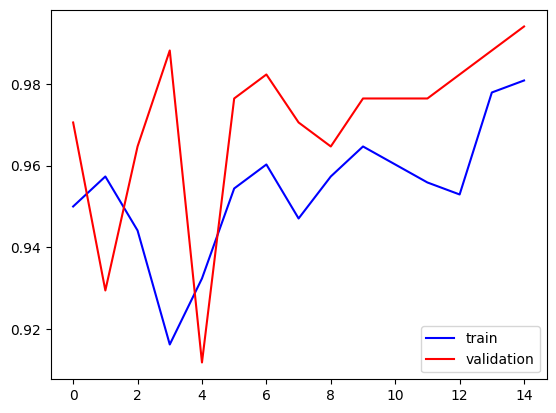

In [ ]:
plt.plot(history.history['accuracy'],color='blue', label='train')
plt.plot(history.history['val_accuracy'],color='red', label='validation')
plt.legend()
plt.show()

Plotting graphs with training and validation loss for each epoch

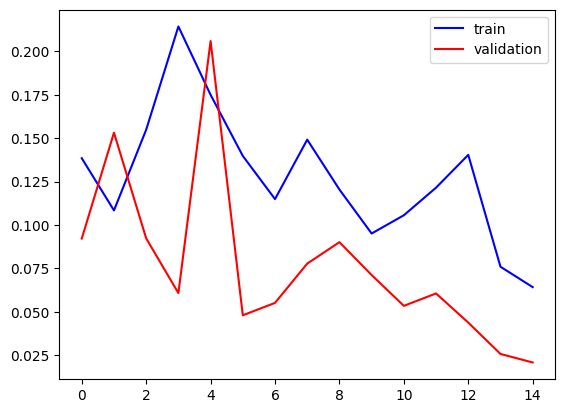

In [ ]:
plt.plot(history.history['loss'],color='blue', label='train')
plt.plot(history.history['val_loss'],color='red', label='validation')
plt.legend()
plt.show()

# 🧪 **Experimental Results**

I have created a table of different iterations of configurations used with their validation scores and their time taken in seconds:

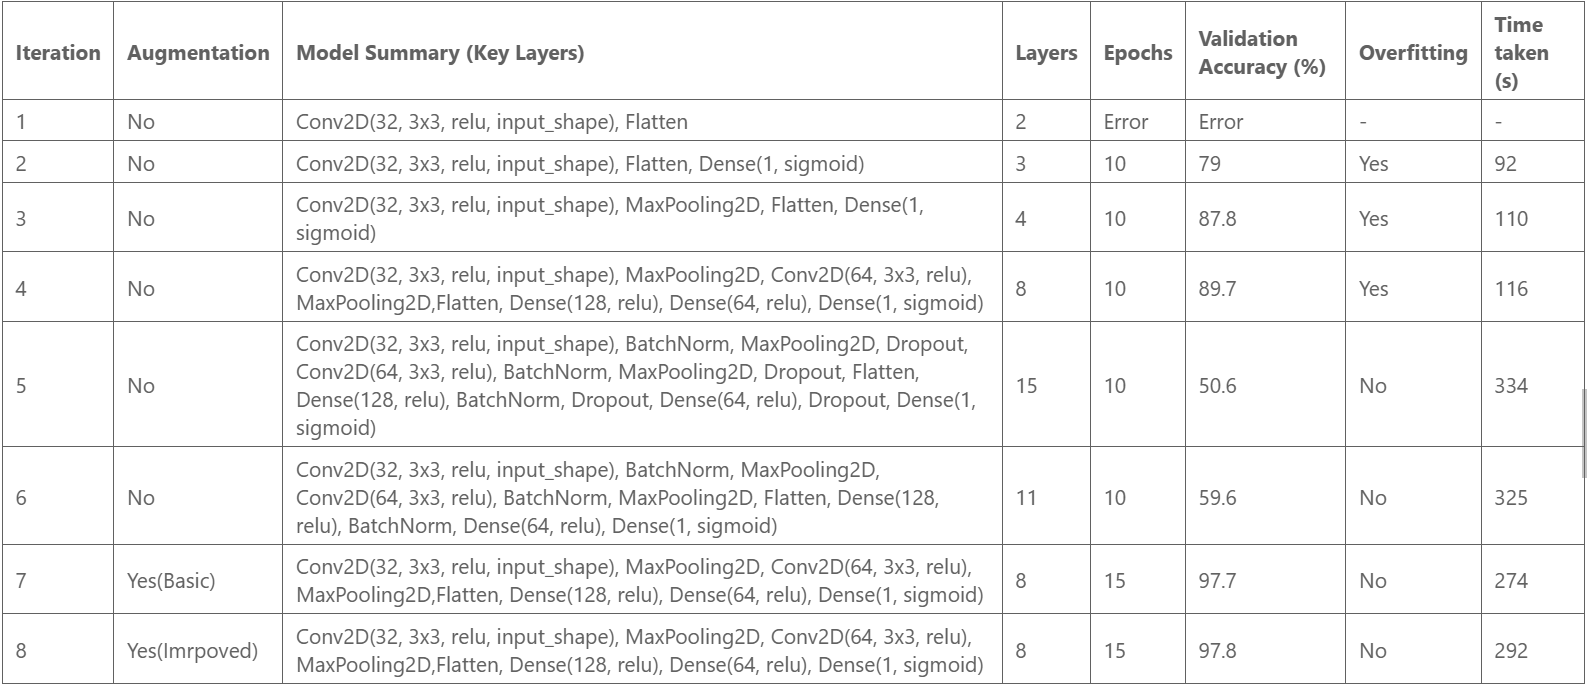

"Basic" augmentation only included rotation, zoom and flip. "Improved" includes all augmentations used in the code.

# 🧐 **Evaluating model on test data**

In [21]:
test_loss, test_accuracy = model.evaluate(test_data)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 224ms/step - accuracy: 0.9768 - loss: 0.0600
Test Loss: 0.0638
Test Accuracy: 0.9800


Confusion matrix for the test results

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


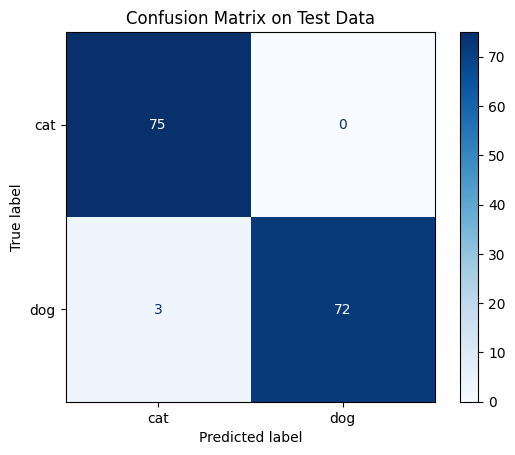

In [22]:
y_true = []
y_pred = []

for i in range(len(test_data)):
    images_batch, labels_batch = test_data[i]
    preds = model.predict(images_batch)
    preds = (preds > 0.5).astype(int).flatten()
    y_true.extend(labels_batch.astype(int))
    y_pred.extend(preds)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = list(test_data.class_indices.keys())
cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix on Test Data")
plt.show()

# ✍🏼 **Model Assessment**



The best model scores a test accuracy of **98.00%** and a test loss of **0.0638** on a test dataset unseen by the model.

The confusion matrix above also shows a very high precision and a recall for both the classes. It also shows signs of very good generalization.

# 💬 **Final Discussion**

**Strengths:**  
- The model scored very high accuracy and also generalized well due to the addition of data augmentation and regularization.
- Using Keras generator allows efficient memory usage.
- CNN helps with automated feature extraction.

**Limitations:**  
- The model's performance can greatly decrease if the images have very poor lighting.
- The model will require retraining if any new animal types are introduced.
- The mode will also require retraining if there is a significant domain shift in the images (for e.g., different breeds or environments).

**Business Implications:**  
- The model provides a strong solution by adding image recognition capabilities to Pedigree's automated food dispenser.
- The strenght of the model will help reduce manual efforts and any possible user errors.
- This product will help build customer trust in Pedigree's smart products.

**Recommendations:**  
- Collect more diverse images to improve model strenght (for e.g., more types of breeds, various coats of fur, vartied environments).
- Retrain the model frequently with new data.

**Deployment:**  
- The model is suitable for deployment as it performs exceptionally well on unseen data.
- Adding a computation device with sufficient computational will help enable real-time inference in the automated dispenser.

# 🏁 **Conclusion**



The pipeline provides a strong and highly scalable solution for Pedigree's automatic food dispenser which will ensure accurate pet recognition and help automate pet care at home or at pet shelters.